# 项目一：鸢尾花分类（监督学习入门）

**目标**：用花的 4 个特征（花萼长、花萼宽、花瓣长、花瓣宽），判断它属于哪一类鸢尾花。

**你会学到**：
- 监督学习的完整流程：加载数据 → 分训练/测试集 → 训练 → 预测 → 评估
- `fit`（学习）和 `predict`（预测）是什么意思
- 如何看准确率和混淆矩阵

> 用法：从上到下，逐个代码块按 `Shift + Enter` 运行。

In [ ]:
# 第 1 步：导入库 + 加载数据
from sklearn.datasets import load_iris                      # 鸢尾花数据集
from sklearn.model_selection import train_test_split        # 划分训练/测试集
from sklearn.linear_model import LogisticRegression         # 逻辑回归模型
from sklearn.neighbors import KNeighborsClassifier          # KNN 模型（稍后对比用）
from sklearn.metrics import accuracy_score, confusion_matrix # 评估指标
import matplotlib.pyplot as plt   # 画图
from sklearn.tree import DecisionTreeClassifier

# 加载数据
iris = load_iris()
X = iris.data      # 特征：每朵花的 4 个数字
y = iris.target    # 标签：0/1/2，代表三种鸢尾花

print("特征 X 的形状:", X.shape)   # (150, 4) = 150 朵花，每朵 4 个特征
print("标签 y 的形状:", y.shape)   # (150,)   = 150 个标签
print("类别名称:", iris.target_names)

特征 X 的形状: (150, 4)
标签 y 的形状: (150,)
类别名称: ['setosa' 'versicolor' 'virginica']


In [4]:
# 第 2 步：看看数据长什么样
print("前 5 朵花的特征（每行一朵花，4 个数字）：")
print(X[:5])

print("\n前 5 朵花的标签：")
print(y[:5])

print("\n含义：0 =", iris.target_names[0],
      " 1 =", iris.target_names[1],
      " 2 =", iris.target_names[2])

前 5 朵花的特征（每行一朵花，4 个数字）：
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

前 5 朵花的标签：
[0 0 0 0 0]

含义：0 = setosa  1 = versicolor  2 = virginica


## 为什么要分「训练集」和「测试集」？

想象老师出题：**先给你 100 道带答案的题让你学（训练集），再出 50 道你没见过的新题考你（测试集）**。

如果拿同一批题又学又考，模型只是「背答案」，换个新题就不会了——这叫**过拟合**。

所以必须分开：训练集用来学，测试集用来客观地打分。

In [26]:
# 第 3 步：划分训练集 / 测试集
# test_size=0.3 表示拿出 30% 当测试集（剩下 70% 训练）
# random_state=42 是随机种子，固定后每次分的结果都一样，方便复现
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=66
)

print("训练集大小:", X_train.shape)   # 105 朵花用来学习
print("测试集大小:", X_test.shape)    # 45 朵花用来考试

训练集大小: (105, 4)
测试集大小: (45, 4)


## 训练模型：`fit` 就是「学习」

下面这行是**监督学习的核心动作**：

```python
model.fit(X_train, y_train)
```

`fit`（拟合）的意思是：把「特征 X」和「答案 y」一起喂给模型，模型自己在内部找规律——「哦，花瓣宽的往往是第 2 类」。

**有监督**的「监督」就体现在这里：学习的时候**每个数据都带着答案**。

In [ ]:
# 第 4 步：创建决策树模型并训练
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)   # fit = 学习，就这一行

print("训练完成！模型已经学会了分类规律。")

训练完成！模型已经学会了分类规律。


In [27]:
# 第 5 步：用测试集「考试」，算准确率
y_pred = model.predict(X_test)   # predict = 预测（模型没见过这些花）

# 准确率 = 预测对的个数 / 总数
acc = accuracy_score(y_test, y_pred)
print(f"准确率: {acc:.2%}")   # :.2% 表示用百分数显示，保留两位小数

# 打印前 10 个预测 vs 真实答案，直观对比
print("\n预测结果:", y_pred[:10])
print("真实答案:", y_test[:10])

准确率: 97.78%

预测结果: [1 1 1 0 1 1 0 0 0 2]
真实答案: [1 1 1 0 1 1 0 0 0 2]


混淆矩阵（行=真实类别，列=预测类别）：
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: G

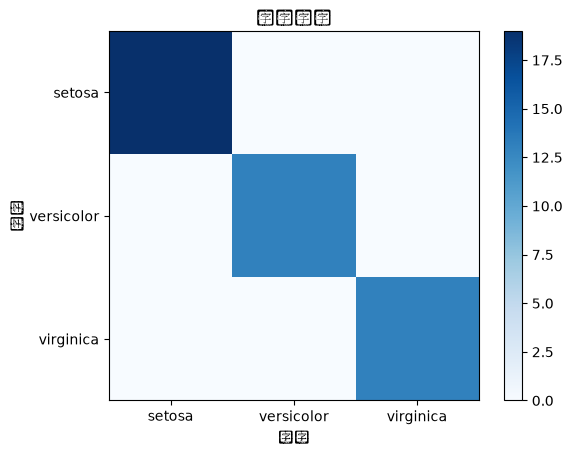

In [8]:
# 第 6 步：画混淆矩阵，看模型在哪几类上容易搞混
cm = confusion_matrix(y_test, y_pred)
print("混淆矩阵（行=真实类别，列=预测类别）：")
print(cm)

# 可视化：颜色越深数字越大，对角线上都是预测对的
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1, 2], iris.target_names)
plt.yticks([0, 1, 2], iris.target_names)
plt.xlabel("预测")
plt.ylabel("真实")
plt.title("混淆矩阵")
plt.show()

In [33]:
# 第 7 步：换一个模型对比 —— KNN（K 近邻）
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))

print(f"逻辑回归准确率: {accuracy_score(y_test, y_pred):.2%}")
print(f"KNN 准确率:      {knn_acc:.2%}")
print("\n不同模型效果可能不同，这就是为什么要多试几个模型。")

逻辑回归准确率: 97.78%
KNN 准确率:      95.56%

不同模型效果可能不同，这就是为什么要多试几个模型。


## 自己动手改（练习）

跑通之后，试着改下面这些地方，观察结果怎么变：

1. 把 `test_size=0.3` 改成 `0.2` 或 `0.5`，准确率会变吗？为什么？
2. 把 `random_state=42` 改成别的数字（比如 0、1、7），准确率会变吗？
3. 把 KNN 的 `n_neighbors=3` 改成 `1`、`5`、`10`，准确率怎么变？
4. 换一个模型：把 `LogisticRegression` 换成 `DecisionTreeClassifier`（决策树，要先 `from sklearn.tree import DecisionTreeClassifier`），效果如何？

**想清楚「为什么结果会变」，比跑通本身更重要。** 卡住了就问我。